In [ ]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns
import xarray as xr
from pandas.plotting import register_matplotlib_converters
from skimage.measure import label
from sklearn.cluster import KMeans
from scipy.signal import find_peaks

register_matplotlib_converters()
sns.set_style("darkgrid")

plt.rc("figure", figsize=(8, 6))
plt.rc("font", size=7)

# Viewing the Data

We consider 2000-2017 geopotential data

In [2]:
# Data
z500 = xr.open_mfdataset('data/5.625deg/geopotential_500/*.nc', combine='by_coords')
data = z500.sel(time=slice('2000', '2017'))

## Global view of the data

Let us look at the mean of the geopotential

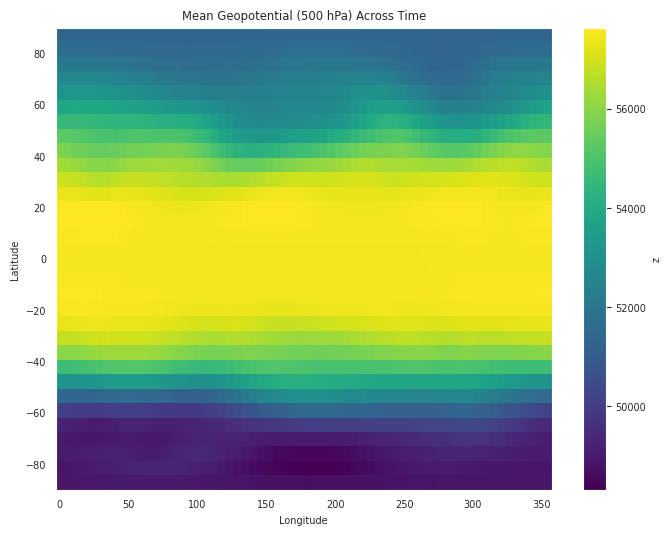

In [3]:
mean_z = data.z.mean(dim='time')
mean_z.plot(cmap='viridis')
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Mean Geopotential (500 hPa) Across Time")
plt.show()

Clearly the geopotential varies along the latitude

Peaks (lat indices): [13 18] Troughs (lat indices): [15]
Peaks (lon indices): [ 8 43 60] Troughs (lon indices): [ 5 22 50 62]


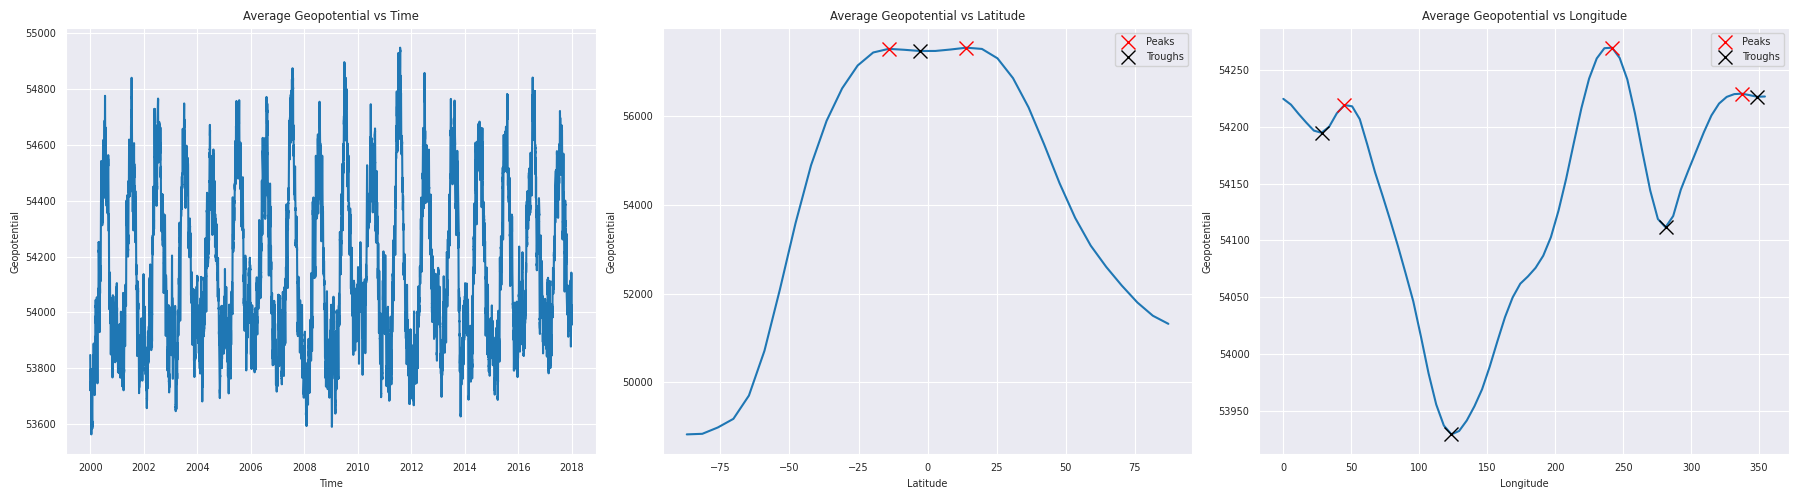

In [ ]:
avg_time = data.z.mean(dim=["lat", "lon"])
avg_lat = data.z.mean(dim=["time", "lon"])
avg_lon = data.z.mean(dim=["time", "lat"])

fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(18, 5))

avg_time.plot(ax=axs[0])
axs[0].set_title("Average Geopotential vs Time")
axs[0].set_xlabel("Time")
axs[0].set_ylabel("Geopotential")

avg_lat.plot(ax=axs[1])
axs[1].set_title("Average Geopotential vs Latitude")
axs[1].set_xlabel("Latitude")
axs[1].set_ylabel("Geopotential")

avg_lon.plot(ax=axs[2])
axs[2].set_title("Average Geopotential vs Longitude")
axs[2].set_xlabel("Longitude")
axs[2].set_ylabel("Geopotential")

# Find peaks and troughs
peaks_lat, _ = find_peaks(avg_lat.values, distance=5)
troughs_lat, _ = find_peaks(-avg_lat.values, distance=5)
peaks_lon, _ = find_peaks(avg_lon.values, distance=5)
troughs_lon, _ = find_peaks(-avg_lon.values, distance=5)
print("Peaks (lat indices):", peaks_lat, "Troughs (lat indices):", troughs_lat)
print("Peaks (lon indices):", peaks_lon, "Troughs (lon indices):", troughs_lon)

# Overlay crosses for latitude peaks and troughs
lat_coords = avg_lat.coords['lat'].values  
axs[1].plot(lat_coords[peaks_lat], avg_lat.values[peaks_lat], 'rx', markersize=10, label="Peaks")
axs[1].plot(lat_coords[troughs_lat], avg_lat.values[troughs_lat], 'kx', markersize=10, label="Troughs")
axs[1].legend()

# Overlay crosses for longitude peaks and troughs
lon_coords = avg_lon.coords['lon'].values  
axs[2].plot(lon_coords[peaks_lon], avg_lon.values[peaks_lon], 'rx', markersize=10, label="Peaks")
axs[2].plot(lon_coords[troughs_lon], avg_lon.values[troughs_lon], 'kx', markersize=10, label="Troughs")
axs[2].legend()

plt.tight_layout()
plt.show()

We can split the latitude into 3 bands 

lat: (0-13, 13-18, 18-32) 

and the longitude into 7 bands

lon: (0-5, 5-8, 8-22, 22-43, 43-50, 50-60, 60-64)

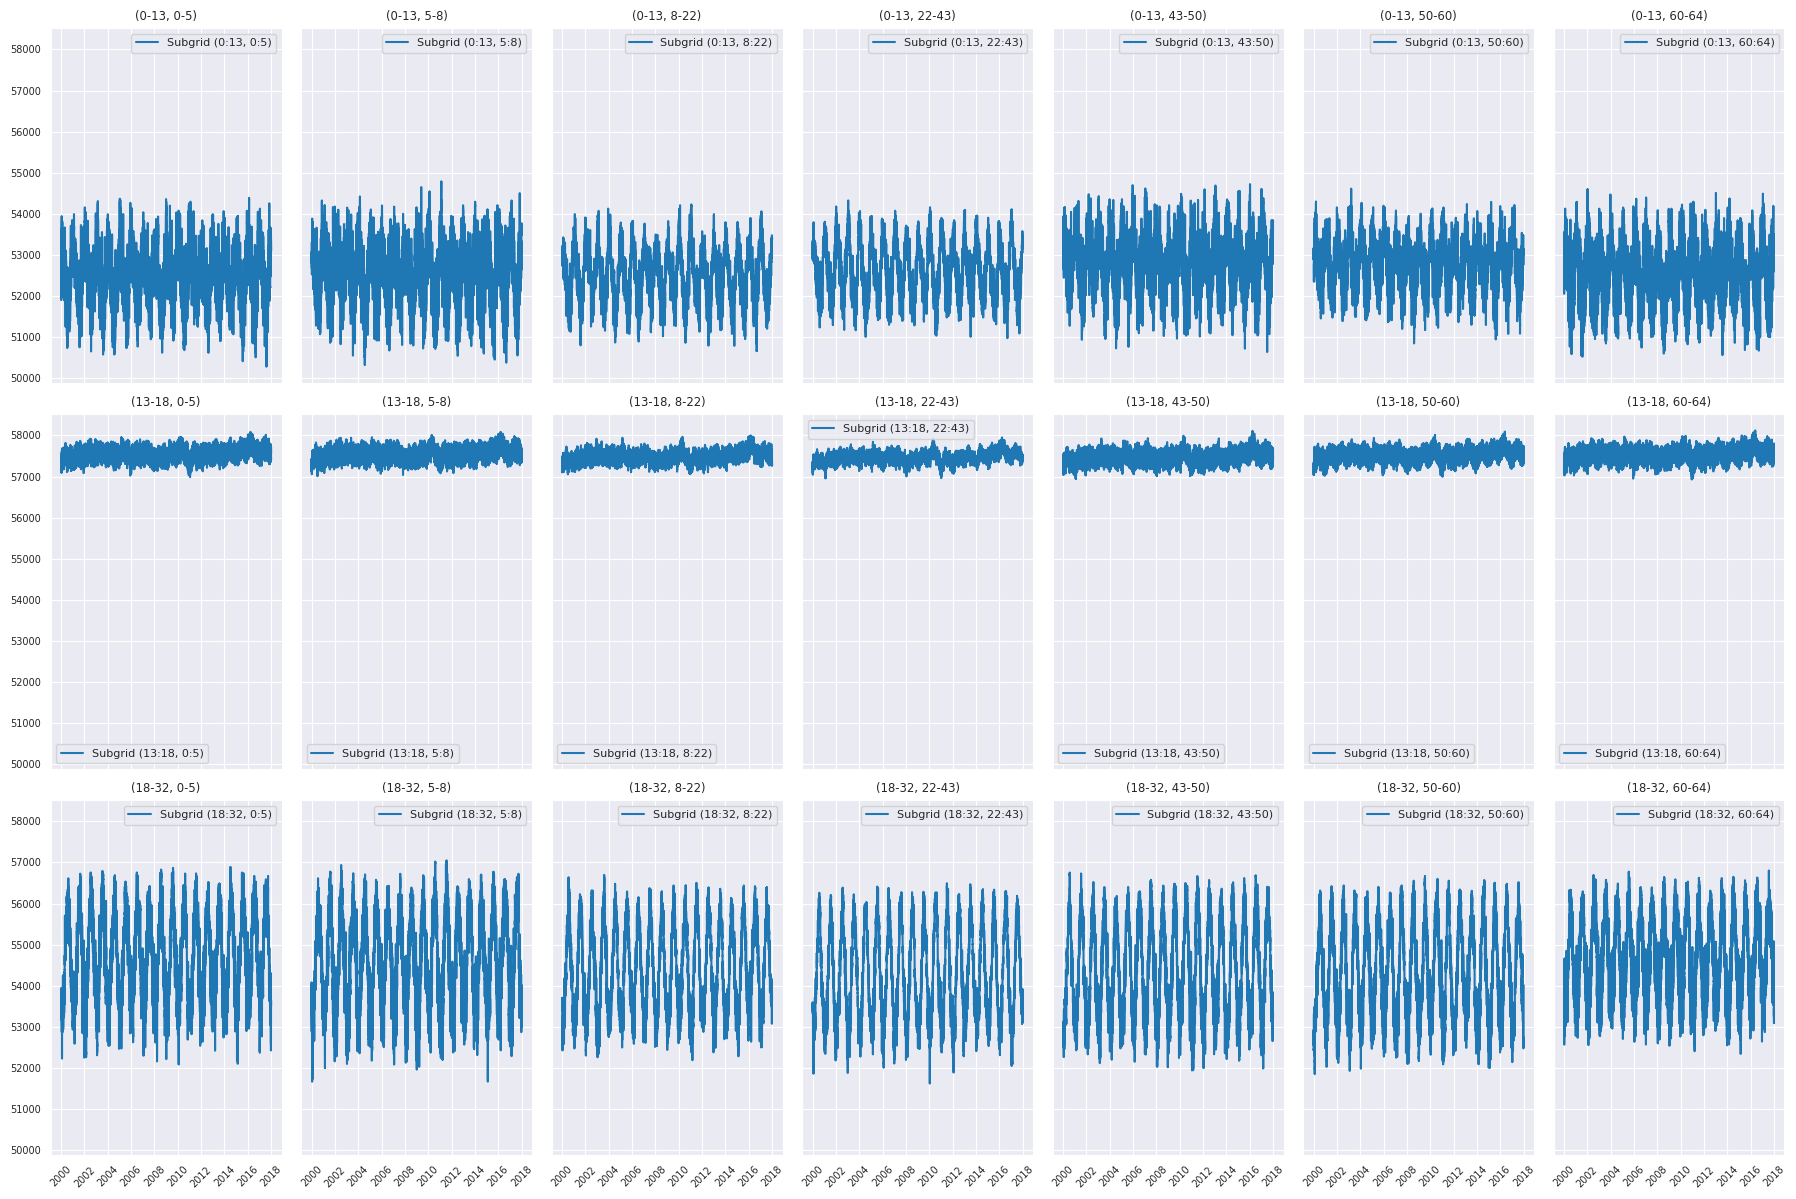

In [5]:
lat_bands = [0,13,18,32]
lon_bands = [0,5,8,22,43,50,60,64]
num_lat_regions = len(lat_bands) - 1
num_lon_regions = len(lon_bands) - 1
# Create a grid of subplots based on trends
fig, axs = plt.subplots(num_lat_regions, num_lon_regions, figsize=(18, 12), sharex=True, sharey=True)
for i in range(num_lat_regions):
    for j in range(num_lon_regions):
        lat_slice = slice(lat_bands[i], lat_bands[i+1])
        lon_slice = slice(lon_bands[j], lon_bands[j+1])
        
        subgrid = data.z.isel(lat=lat_slice, lon=lon_slice)
        subgrid_mean = subgrid.mean(dim=["lat", "lon"])
    
        ax = axs[i, j] if num_lat_regions > 1 else axs[j]
        ax.plot(subgrid_mean.time, subgrid_mean, label=f"Subgrid ({lat_bands[i]}:{lat_bands[i+1]}, {lon_bands[j]}:{lon_bands[j+1]})")
        ax.set_title(f"({lat_bands[i]}-{lat_bands[i+1]}, {lon_bands[j]}-{lon_bands[j+1]})")
        ax.tick_params(axis='x', labelrotation=45)
        ax.legend(fontsize=8)
        
plt.tight_layout()
plt.show()

Now if we look at the std dev instead of the mean

Peaks (lat indices): [ 6 27] Troughs (lat indices): [15]
Peaks (lon indices): [ 1 10 26 35 49] Troughs (lon indices): [ 5 14 30 42 62]


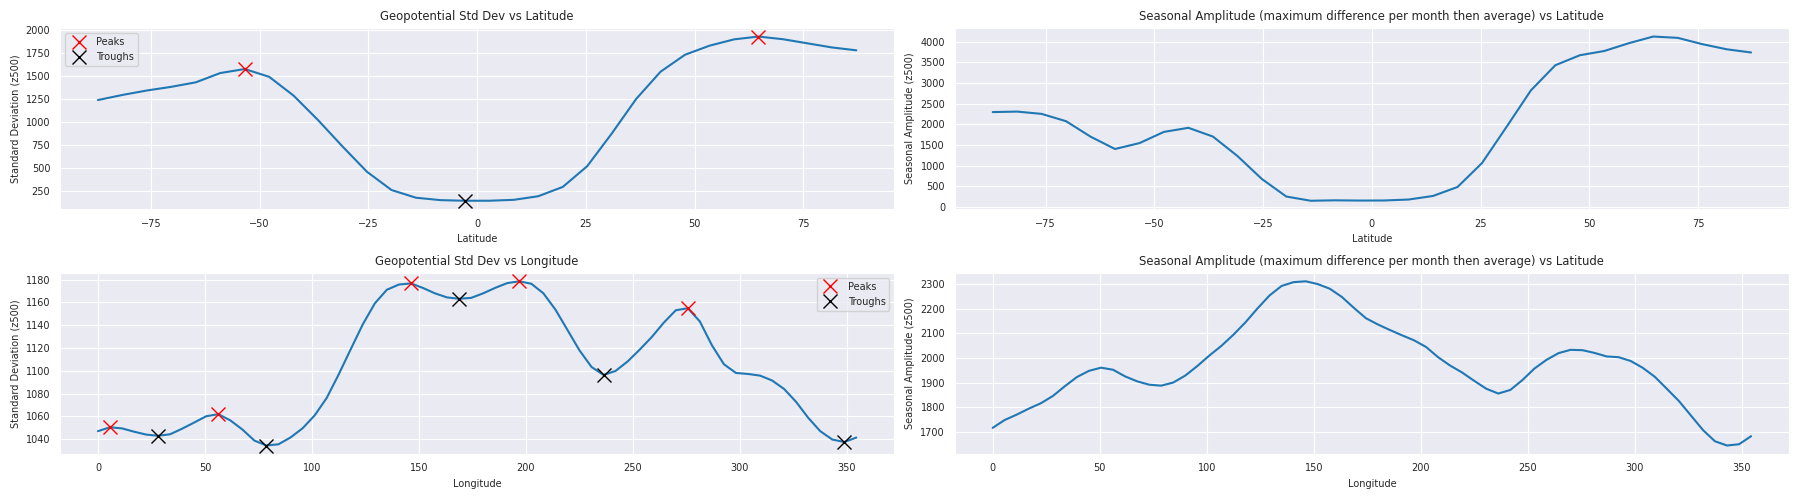

In [ ]:
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(18, 5))

z_std = data.z.std(dim="time")
z_std_lat = z_std.mean(dim="lon")
z_std_lon = z_std.mean(dim="lat")

z_monthly = data.z.groupby("time.month").mean("time")
z_seasonal_amp = z_monthly.max(dim="month") - z_monthly.min(dim="month")
z_seasonal_amp_lat = z_seasonal_amp.mean(dim="lon")
z_seasonal_amp_lon = z_seasonal_amp.mean(dim="lat")

z_std_lat.plot(ax=axs[0][0])
axs[0][0].set_title("Geopotential Std Dev vs Latitude")
axs[0][0].set_xlabel("Latitude")
axs[0][0].set_ylabel("Standard Deviation (z500)")

z_seasonal_amp_lat.plot(ax=axs[0][1])
axs[0][1].set_title("Seasonal Amplitude (maximum difference per month then average) vs Latitude")
axs[0][1].set_xlabel("Latitude")
axs[0][1].set_ylabel("Seasonal Amplitude (z500)")

z_std_lon.plot(ax=axs[1][0])
axs[1][0].set_title("Geopotential Std Dev vs Longitude")
axs[1][0].set_xlabel("Longitude")
axs[1][0].set_ylabel("Standard Deviation (z500)")

z_seasonal_amp_lon.plot(ax=axs[1][1])
axs[1][1].set_title("Seasonal Amplitude (maximum difference per month then average) vs Latitude")
axs[1][1].set_xlabel("Longitude")
axs[1][1].set_ylabel("Seasonal Amplitude (z500)")

# Find peaks and troughs
peaks_lat, _ = find_peaks(z_std_lat.values, distance=5)
troughs_lat, _ = find_peaks(-z_std_lat.values, distance=5)
peaks_lon, _ = find_peaks(z_std_lon.values, distance=5)
troughs_lon, _ = find_peaks(-z_std_lon.values, distance=5)

print("Peaks (lat indices):", peaks_lat, "Troughs (lat indices):", troughs_lat)
print("Peaks (lon indices):", peaks_lon, "Troughs (lon indices):", troughs_lon)

# Overlay crosses for latitude peaks and troughs
lat_coords = z_std_lat.coords['lat'].values  
axs[0][0].plot(lat_coords[peaks_lat], z_std_lat.values[peaks_lat], 'rx', markersize=10, label="Peaks")
axs[0][0].plot(lat_coords[troughs_lat], z_std_lat.values[troughs_lat], 'kx', markersize=10, label="Troughs")
axs[0][0].legend()

# Overlay crosses for longitude peaks and troughs
lon_coords = z_std_lon.coords['lon'].values  
axs[1][0].plot(lon_coords[peaks_lon], z_std_lon.values[peaks_lon], 'rx', markersize=10, label="Peaks")
axs[1][0].plot(lon_coords[troughs_lon], z_std_lon.values[troughs_lon], 'kx', markersize=10, label="Troughs")
axs[1][0].legend()

plt.tight_layout()
plt.show()

Similarly, splitting the grid based on the stddev 

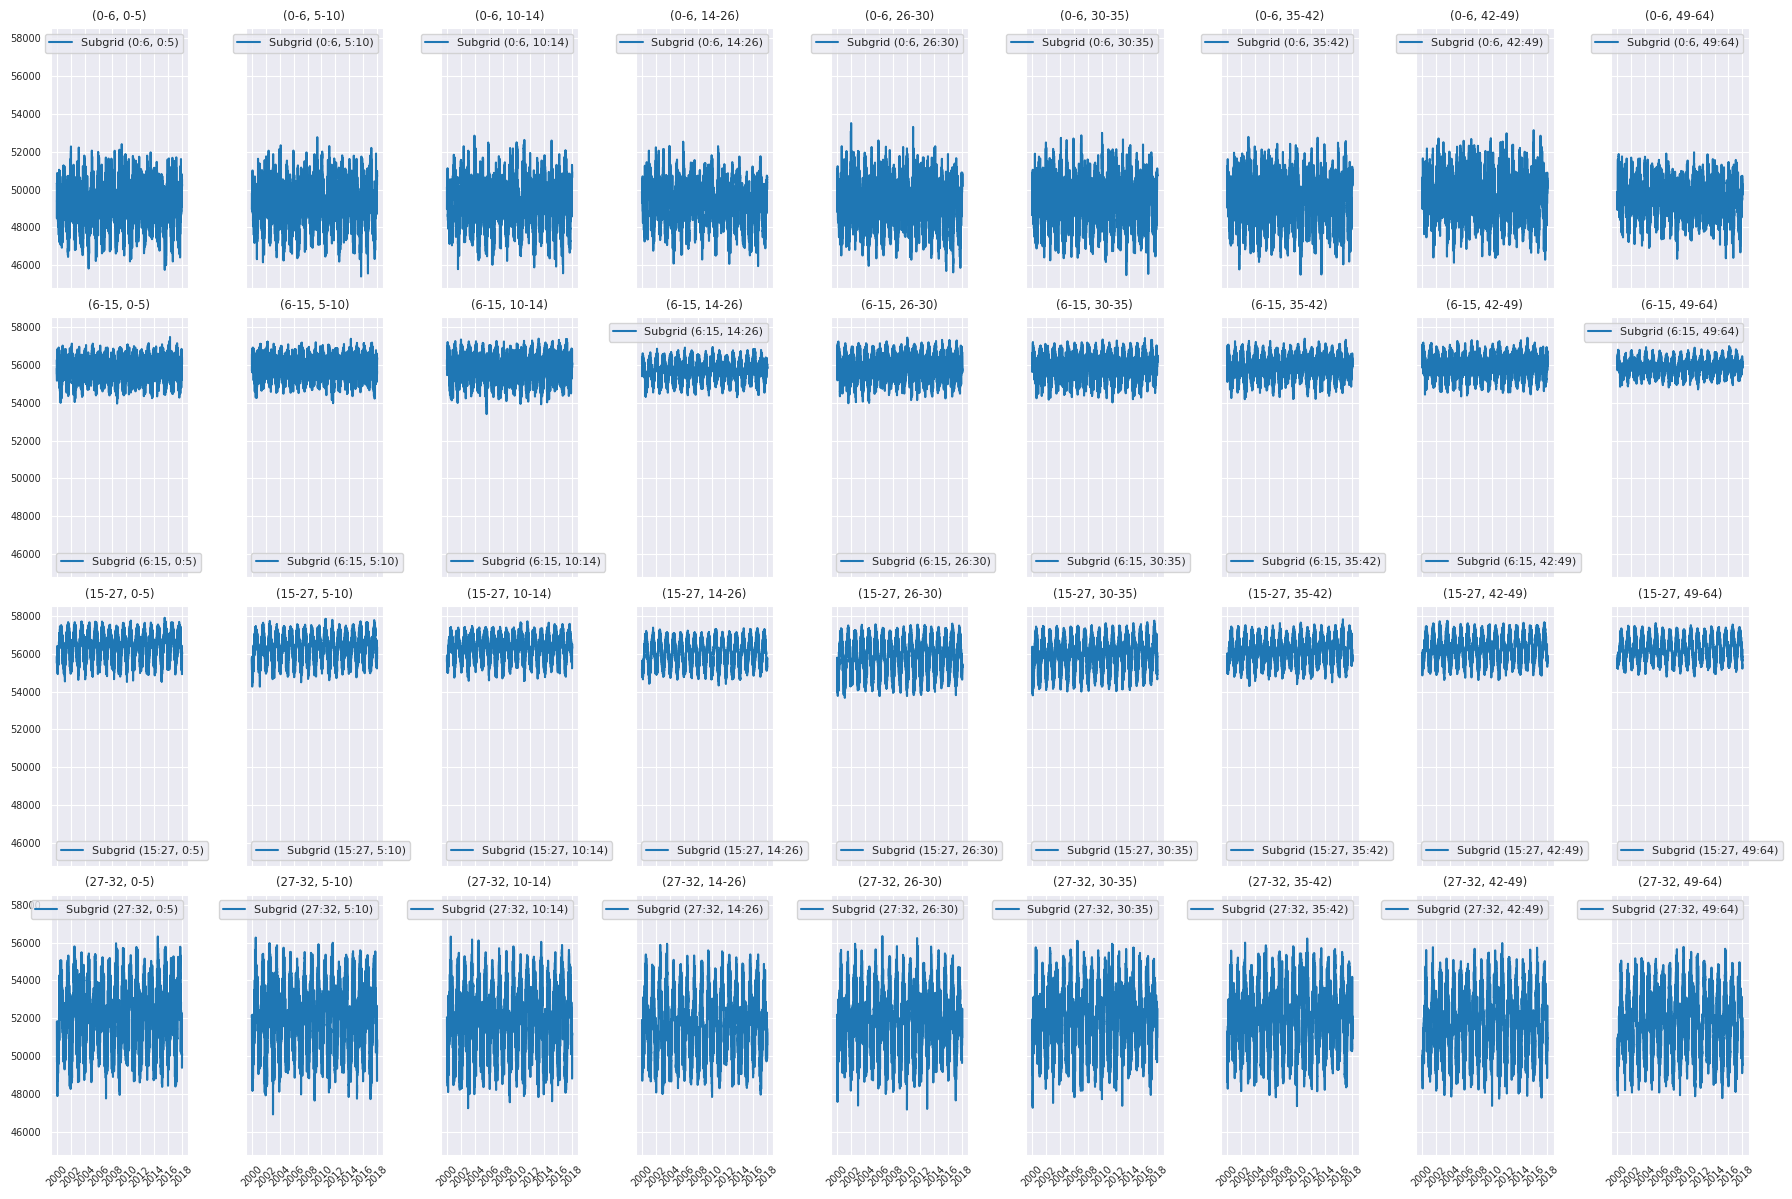

In [7]:
lat_bands = [0,6,15,27,32]
lon_bands = [0,5,10,14,26,30,35,42,49,64]
num_lat_regions = len(lat_bands) - 1
num_lon_regions = len(lon_bands) - 1
fig, axs = plt.subplots(num_lat_regions, num_lon_regions, figsize=(18, 12), sharex=True, sharey=True)
for i in range(num_lat_regions):
    for j in range(num_lon_regions):
        lat_slice = slice(lat_bands[i], lat_bands[i+1])
        lon_slice = slice(lon_bands[j], lon_bands[j+1])
        
        subgrid = data.z.isel(lat=lat_slice, lon=lon_slice)
        subgrid_mean = subgrid.mean(dim=["lat", "lon"])
        
        ax = axs[i, j] if num_lat_regions > 1 else axs[j]
        ax.plot(subgrid_mean.time, subgrid_mean, label=f"Subgrid ({lat_bands[i]}:{lat_bands[i+1]}, {lon_bands[j]}:{lon_bands[j+1]})")
        ax.set_title(f"({lat_bands[i]}-{lat_bands[i+1]}, {lon_bands[j]}-{lon_bands[j+1]})")
        ax.tick_params(axis='x', labelrotation=45)
        ax.legend(fontsize=8)
        
plt.tight_layout()
plt.show()

## Data periods

We see the data has some annual periodicity.

In [8]:
fs = 1 # Data sampled hourly
T = data.z.values.shape[0]

fft_vals = np.fft.rfft(data.z.values, axis=0)  
freqs = np.fft.rfftfreq(T, d=1/fs)  
power = np.abs(fft_vals)**2  

power_nozero = power[1:]     
freqs_nozero = freqs[1:]       

sorted_idx = np.argsort(power_nozero, axis=0)
dom_idx = sorted_idx[-1, :, :]
second_dom_idx = sorted_idx[-2, :, :]

dom_freq = freqs_nozero[dom_idx] 
second_dom_freq = freqs_nozero[second_dom_idx] 

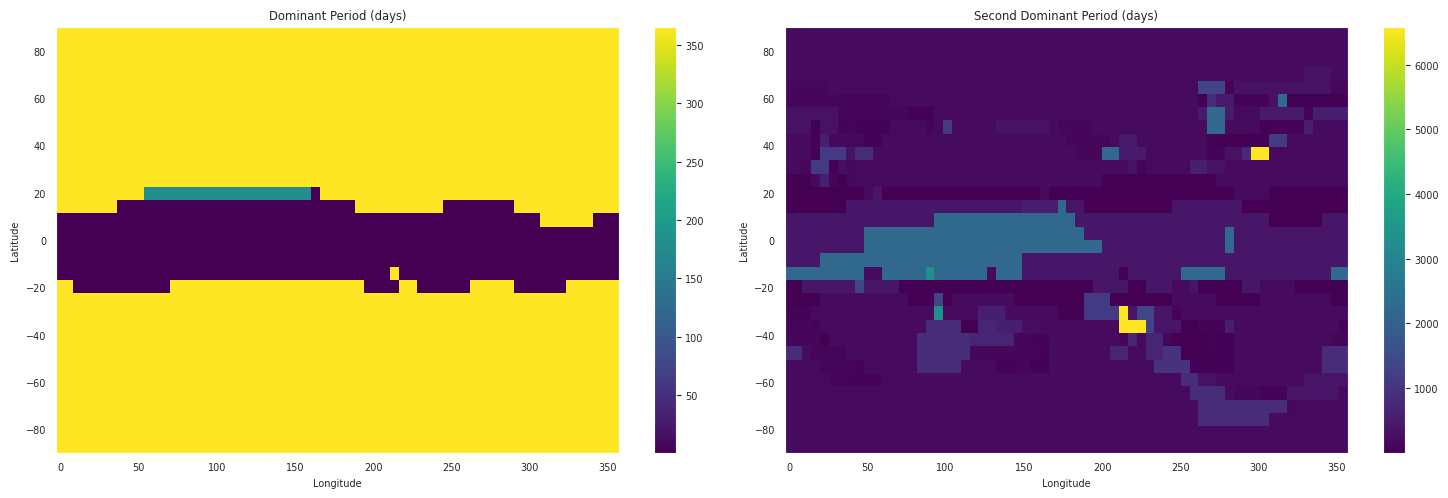

In [9]:
dom_period = 1.0 / dom_freq; dom_period_days = dom_period / 24.0
second_dom_period = 1.0 / second_dom_freq; second_dom_period_days = second_dom_period / 24.0 

dom_period_da = xr.DataArray(dom_period_days, coords=[data.lat, data.lon], dims=["lat", "lon"])
second_dom_period_da = xr.DataArray(second_dom_period_days, coords=[data.lat, data.lon], dims=["lat", "lon"])

fig, axs = plt.subplots(ncols=2, figsize=(15, 5))

dom_period_da.plot(ax=axs[0], cmap="viridis")
axs[0].set_title("Dominant Period (days)")
axs[0].set_xlabel("Longitude")
axs[0].set_ylabel("Latitude")

second_dom_period_da.plot(ax=axs[1], cmap="viridis")
axs[1].set_title("Second Dominant Period (days)")
axs[1].set_xlabel("Longitude")
axs[1].set_ylabel("Latitude")

plt.tight_layout()
plt.show()

Cluseter up the regions

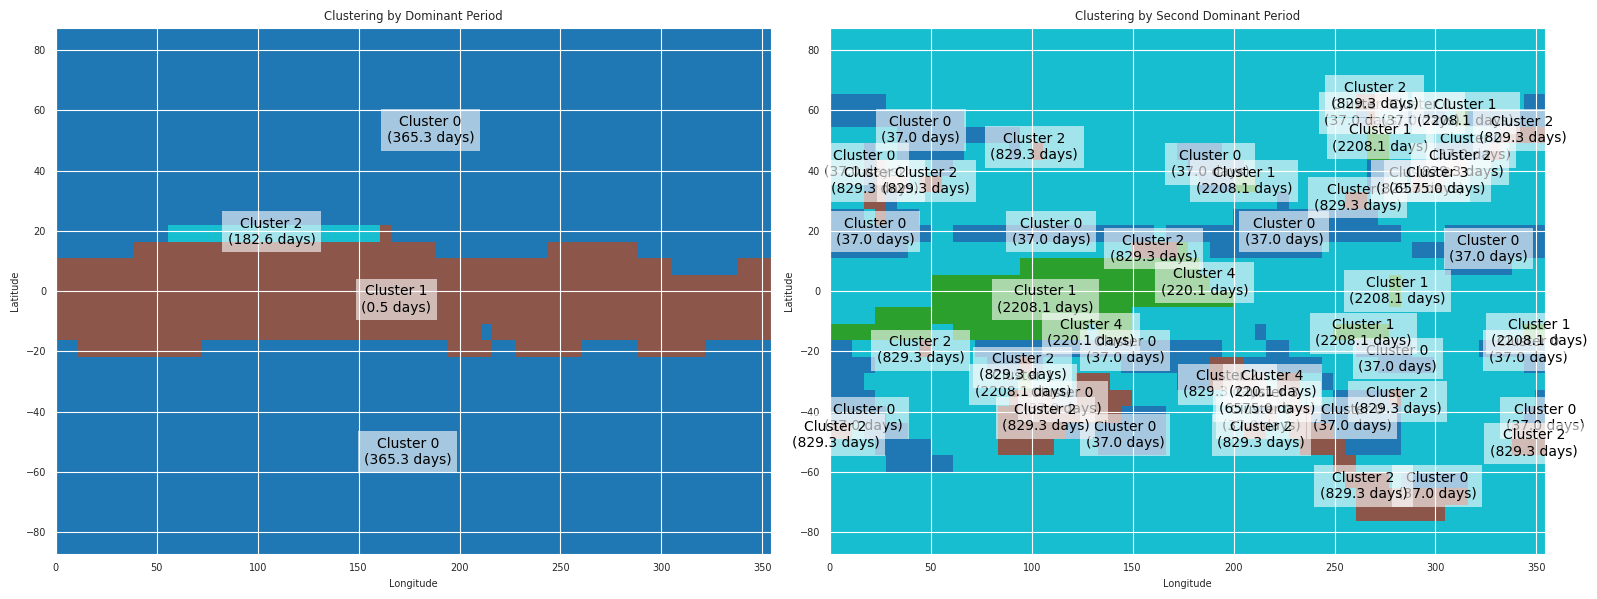

In [10]:
period_flat = dom_period_da.values.flatten().reshape(-1, 1)

kmeans = KMeans(n_clusters=3, random_state=42).fit(period_flat)
cluster_labels = kmeans.labels_.reshape(dom_period_da.shape)
cluster_da = xr.DataArray(cluster_labels, coords=[data.lat, data.lon], dims=["lat", "lon"])

period2_flat = second_dom_period_da.values.flatten().reshape(-1, 1)
kmeans2 = KMeans(n_clusters=5, random_state=42).fit(period2_flat)
cluster_labels2 = kmeans2.labels_.reshape(second_dom_period_da.shape)
cluster_da2 = xr.DataArray(cluster_labels2, coords=[data.lat, data.lon], dims=["lat", "lon"])

lat_vals = cluster_da.coords["lat"].values
lon_vals = cluster_da.coords["lon"].values
nrows, ncols = cluster_da.shape

x_coords = np.linspace(lon_vals.min(), lon_vals.max(), ncols)
y_coords = np.linspace(lat_vals.min(), lat_vals.max(), nrows)
centers = kmeans.cluster_centers_.flatten()  

nrows2, ncols2 = cluster_da2.shape
x_coords2 = np.linspace(lon_vals.min(), lon_vals.max(), ncols2)
y_coords2 = np.linspace(lat_vals.min(), lat_vals.max(), nrows2)
centers2 = kmeans2.cluster_centers_.flatten()

fig, axs = plt.subplots(ncols=2, figsize=(16, 6))

im0 = axs[0].imshow(cluster_da.values, cmap="tab10", origin="lower",
                     extent=[lon_vals.min(), lon_vals.max(), lat_vals.min(), lat_vals.max()],
                     aspect="auto")
axs[0].set_title("Clustering by Dominant Period")
axs[0].set_xlabel("Longitude")
axs[0].set_ylabel("Latitude")

unique_clusters = np.unique(cluster_da.values)
for clust in unique_clusters:
    if clust < 0:
        continue
    mask = (cluster_da.values == clust)
    labeled_components = label(mask)
    for comp_label in np.unique(labeled_components):
        if comp_label == 0:
            continue  # Skip background
        comp_idx = np.where(labeled_components == comp_label)
        avg_row = np.median(comp_idx[0])
        avg_col = np.median(comp_idx[1])
        x_val = np.interp(avg_col, np.arange(ncols), x_coords)
        y_val = np.interp(avg_row, np.arange(nrows), y_coords)
        axs[0].text(x_val, y_val, f"Cluster {int(clust)}\n({centers[int(clust)]:.1f} days)",
                    color="black", ha="center", va="center", fontsize=10,
                    bbox=dict(facecolor="white", alpha=0.6, edgecolor="none"))

im1 = axs[1].imshow(cluster_da2.values, cmap="tab10", origin="lower",
                     extent=[lon_vals.min(), lon_vals.max(), lat_vals.min(), lat_vals.max()],
                     aspect="auto")
axs[1].set_title("Clustering by Second Dominant Period")
axs[1].set_xlabel("Longitude")
axs[1].set_ylabel("Latitude")

unique_clusters2 = np.unique(cluster_da2.values)
for clust in unique_clusters2:
    if clust < 0:
        continue
    mask = (cluster_da2.values == clust)
    labeled_components = label(mask)
    for comp_label in np.unique(labeled_components):
        if comp_label == 0:
            continue
        comp_idx = np.where(labeled_components == comp_label)
        avg_row = np.median(comp_idx[0])
        avg_col = np.median(comp_idx[1])
        x_val = np.interp(avg_col, np.arange(ncols2), x_coords2)
        y_val = np.interp(avg_row, np.arange(nrows2), y_coords2)
        axs[1].text(x_val, y_val, f"Cluster {int(clust)}\n({centers2[int(clust)]:.1f} days)",
                    color="black", ha="center", va="center", fontsize=10,
                    bbox=dict(facecolor="white", alpha=0.6, edgecolor="none"))

plt.tight_layout()
plt.show()